# Demonstrates the trans / cis ratio at different irradiance values

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.fluorophore_systems as fs
import src.miscellaneous as mi
import src.processing as pr
import src.custom_plot as cp
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'pycorrelate'

In [2]:
system = fs.Cy5(number_fluorophores=1, distances=1, user=user, irradiance=2.5, 
                wavelength=640, dstorm_parameters=dict(),
                remove=['CFRET', 'TFRET', 'HFRET', 'OFRET', 'RED', 'OX'])

(<Figure size 600x400 with 1 Axes>, <AxesSubplot:>)

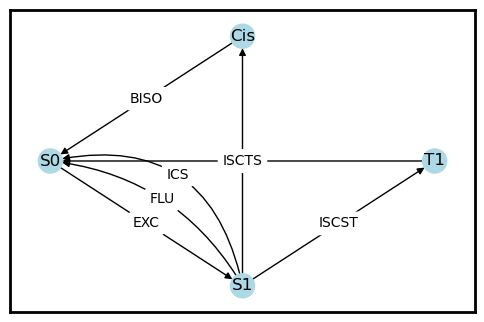

In [36]:
system.plot.network(colors=['#ADD8E6', 'red'])

In [3]:
system.unique_transitions

,name,rate,trivial_name,abbreviation,fluorescence
id,,,,,
0,S0_S1,7.27e+06,excitation,EXC,False
1,S1_S0,2.70e+08,fluorescent emission,FLU,True
2,S1_T1,8.30e+05,intersystem crossing ST,ISCST,False
3,S1_S0,7.09e+08,internal conversion S,ICS,False
4,S1_Cis,2.00e+07,isomerization,ISO,False
5,Cis_S0,1.37e+05,backisomerization,BISO,False
6,T1_S0,5.00e+05,intersystem crossing TS,ISCTS,False


In [8]:
system.single_states

{0: 'S0', 1: 'S1', 2: 'T1', 3: 'Cis'}

In [19]:
irradiances = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
rng = np.random.default_rng(100)

number_single_states = len(system.single_states)
relative_lifetimes_all = np.empty((len(irradiances), number_single_states + 1))
for j, irradiance in enumerate(irradiances):
    system = fs.Cy5(number_fluorophores=1, distances=1, user=user, irradiance=irradiance, 
                wavelength=640, dstorm_parameters=dict(),
                remove=['CFRET', 'TFRET', 'HFRET', 'OFRET', 'RED', 'OX'])
    mean_lifetimes, _, _, _ = pr.predict_lifetimes(system.single_states, system.unique_transitions)
    single_state_occurrences, _ = pr.predict_occurrences(system.single_states, system.unique_transitions, mean_lifetimes)
    total_lifetimes = single_state_occurrences * mean_lifetimes
    
    total_lifetimes_pred_sum_all = total_lifetimes.sum()
    trans_lifetime = total_lifetimes[:-1].sum()
    
    relative_lifetimes = np.empty(number_single_states + 1)
    for i in range(number_single_states):
        state_lifetime = total_lifetimes[i]
        relative_lifetimes[i] = state_lifetime / total_lifetimes_pred_sum_all
    relative_lifetimes[-1] = trans_lifetime / (relative_lifetimes[-2] * total_lifetimes_pred_sum_all)
    
    relative_lifetimes_all[j] = relative_lifetimes


    

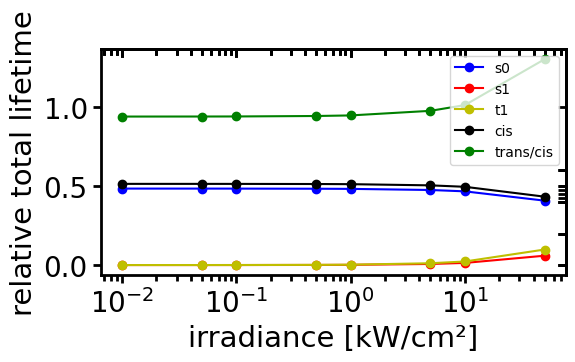

In [29]:
fig, ax = cp.universal_figure(data=[irradiances, relative_lifetimes_all[:, 0]], label='s0', marker='o')
legends = ['s1', 't1', 'cis', 'trans/cis']
colors = ['r', 'y', 'k', 'g']
for i in range(relative_lifetimes_all.shape[1] - 1):
    _, _ = cp.universal_figure(data=[irradiances, relative_lifetimes_all[:, i+1]], label=legends[i], marker='o',
                               fig=fig, axes=ax[0], legend=True, xscale='log', xlabel='irradiance [kW/cm²]',
                               color=colors[i], ylabel='relative total lifetime')